In [295]:
import os
try:
    os.chdir("aulas_teoricas")
except FileNotFoundError:
    pass

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import dump, load
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

from src.line_equation import Line_equation
from src.functions import Functions

In [296]:
def func_dados(valor) -> float:
    valor_final = 5 + valor*2
    return valor_final

In [297]:
n = 200
b = np.random.randint(1, 20, n)
b[:10]

array([16, 15,  7, 16, 15, 11,  8,  2,  3,  7])

In [298]:
a = np.apply_along_axis(func_dados, 0, b)
a[:10]

array([37, 35, 19, 37, 35, 27, 21,  9, 11, 19])

In [299]:
df = pd.DataFrame(
    data={
        'x': a,
        'y': b
    }
).round(0)
df.head()

,x,y
0,37,16
1,35,15
2,19,7
3,37,16
4,35,15


In [300]:
def func_dados_erro(valor: int) -> float:
    erro = np.random.normal(0, 2, 1)
    valor_final = valor + erro[0]
    return valor_final

In [301]:
df['x_noise'] = df['x'].apply(func=func_dados_erro)
df['y_noise'] = df['y'].apply(func=func_dados_erro)
df.head()

,x,y,x_noise,y_noise
0,37,16,34.450019,16.417848
1,35,15,33.979595,12.646505
2,19,7,16.978169,7.785188
3,37,16,39.378439,18.198745
4,35,15,30.842966,16.125124


In [302]:
def novo_valor(valor: int, correct: float, q1y: float, q3y: float) -> float:
    if valor <= q1y:
        return valor + correct
    if valor >= q3y:
        return valor + correct
    return valor

In [303]:
q1y = df.y_noise.quantile(.25)
q3y = df.y_noise.quantile(.75)

df['y_noise_new'] = df['y_noise'].apply(func=novo_valor, args=(5, q1y, q3y))
df.head()

,x,y,x_noise,y_noise,y_noise_new
0,37,16,34.450019,16.417848,21.417848
1,35,15,33.979595,12.646505,12.646505
2,19,7,16.978169,7.785188,7.785188
3,37,16,39.378439,18.198745,23.198745
4,35,15,30.842966,16.125124,21.125124


In [304]:
minx = df.x_noise.min()
q1x = df.x_noise.quantile(.25)
q3x = df.x_noise.quantile(.75)
maxx = df.x_noise.max()

miny = df.y_noise_new.min()
q1y = df.y_noise_new.quantile(.25)
q3y = df.y_noise_new.quantile(.75)
maxy = df.y_noise_new.max()

noise = pd.DataFrame({
    'x':[minx, q1x, q3x, maxx],
    'y':[miny, q1y, q3y, maxy],
})
noise

,x,y
0,4.082802,3.984229
1,16.413444,7.429543
2,32.421149,15.539886
3,45.802600,27.107754


In [305]:
lista_valores = list()

[lista_valores.append(x) for x in np.random.randint(minx, q1x, 50)]
[lista_valores.append(x) for x in np.random.randint(q1x, q3x, 100)]
[lista_valores.append(x) for x in np.random.randint(q3x, maxx, 50)]

df["x_noise_mean"] = np.array(lista_valores)

lista_valores = list()

[lista_valores.append(y) for y in np.random.randint(miny, q1y, 50)]
[lista_valores.append(y) for y in np.random.randint(q1y, q3y, 100)]
[lista_valores.append(y) for y in np.random.randint(q3y, maxy, 50)]

df["y_noise_mean"] = np.array(lista_valores)

df.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean
0,37,16,34.450019,16.417848,21.417848,11,3
1,35,15,33.979595,12.646505,12.646505,14,3
2,19,7,16.978169,7.785188,7.785188,15,4
3,37,16,39.378439,18.198745,23.198745,5,6
4,35,15,30.842966,16.125124,21.125124,8,5


In [306]:
df_1 = df.sample(frac=.5)
df_2 = df.sample(frac=.5)

In [307]:
df_1['class'] = True
df_1.loc[df_1['x_noise'].sample(frac=.75).index, 'class'] = False
df_1['class'].value_counts()

False    75
True     25
Name: class, dtype: int64

In [308]:
df_1['style'] = "o"
df_1.loc[df_1[df_1['class']].index, 'style'] = '+'
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style
60,15,5,13.866179,2.450170,7.450170,30,11,False,o
16,35,15,36.015962,12.175344,12.175344,6,6,True,+
6,21,8,20.499881,6.734718,6.734718,8,5,False,o
187,15,5,16.470244,5.053117,10.053117,32,17,False,o
12,29,12,27.601893,4.480009,9.480009,4,4,True,+


In [309]:
df_1['style'].value_counts()

o    75
+    25
Name: style, dtype: int64

In [310]:
df_1['style_2'] = "o"
df_1.loc[df_1[df_1['y_noise_new'] > 17].index, 'style_2'] = '+'
df_1.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2
60,15,5,13.866179,2.450170,7.450170,30,11,False,o,o
16,35,15,36.015962,12.175344,12.175344,6,6,True,+,o
6,21,8,20.499881,6.734718,6.734718,8,5,False,o,o
187,15,5,16.470244,5.053117,10.053117,32,17,False,o,o
12,29,12,27.601893,4.480009,9.480009,4,4,True,+,o


In [311]:
# dump(df_1, './data/01_aula_df_1')
# dump(df_2, './data/01_aula_df_2')
# dump(df, './data/01_aula_df')

In [312]:
df = load('./data/01_aula_df')
df_1 = load('./data/01_aula_df_1')
df_2 = load('./data/01_aula_df_2')

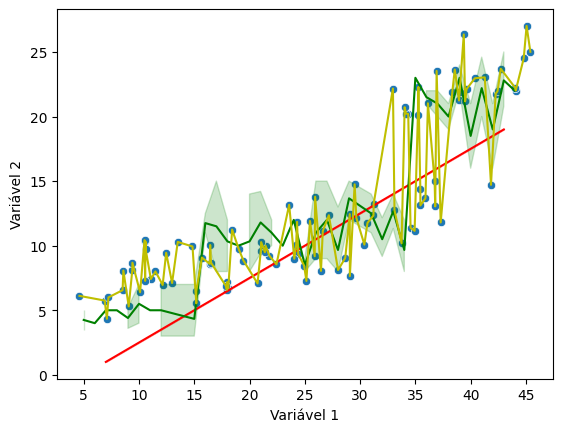

In [313]:
obsr = "Variável 1"
pred = "Variável 2"
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    data=df_1
)
sns.lineplot(
    x='x',
    y='y',
    data=df_1,
    c='r',
)
sns.lineplot(
    x='x_noise_mean',
    y='y_noise_mean',
    data=df_1,
    c='g',
)
sns.lineplot(
    x='x_noise',
    y='y_noise_new',
    data=df_1,
    c='y',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.show()

In [314]:
print(f"RMSE red: {mean_squared_error(df['x'], df['y'])}")
print(f"RMSE gree: {mean_squared_error(df['x_noise_mean'], df['y_noise_mean'])}")
print(f"RMSE yellow: {mean_squared_error(df['x_noise'], df['x_noise'])}")

RMSE red: 262.015
RMSE gree: 212.83
RMSE yellow: 0.0


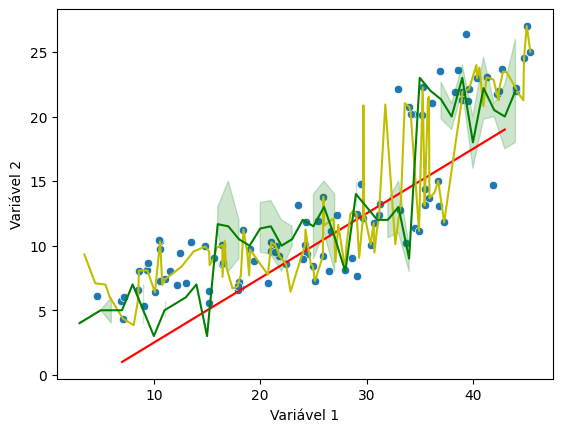

In [315]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    data=df_1
)
sns.lineplot(
    x='x',
    y='y',
    data=df_2,
    c='r',
)
sns.lineplot(
    x='x_noise',
    y='y_noise_new',
    data=df_2,
    c='y',
)
sns.lineplot(
    x='x_noise_mean',
    y='y_noise_mean',
    data=df_2,
    c='g',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.show()

In [316]:
print(f"RMSE red: {mean_squared_error(df_1['x'], df_2['y'])}")
print(f"RMSE gree: {mean_squared_error(df_1['x_noise_mean'], df_2['y_noise_mean'])}")
print(f"RMSE yellow: {mean_squared_error(df_1['x_noise'], df_2['x_noise'])}")

RMSE red: 361.89
RMSE gree: 367.56
RMSE yellow: 253.16193214948495


---

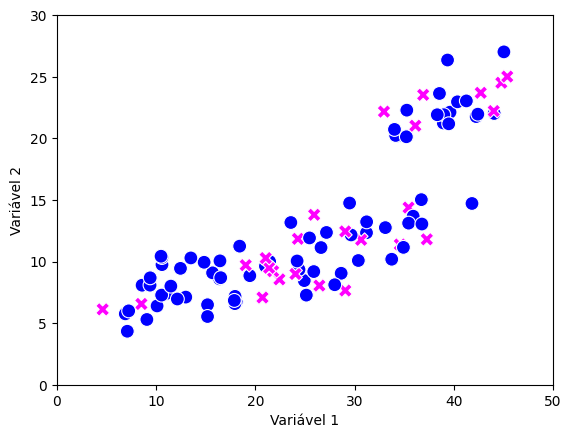

In [317]:
palette = {False:'blue', True:'magenta'}
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='class',
    style='style',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

In [318]:
def calcular_valor_por_dia(dia: int, valor_inicial: float) -> float:
    """Calcula o valor para um dia específico seguindo a regra:
    - Dias 1 a 4: valor original
    - Dias 5 a 8: incremento de 10% do valor inicial
    - Repete a cada ciclo de 8 dias.
    """
    if dia < 1:
        raise ValueError("O dia deve ser maior ou igual a 1.")
        
    # O operador % (resto da divisão) nos ajuda a mapear 
    # qualquer dia para sua posição equivalente dentro do ciclo de 8 dias (0 a 7)
    posicao_no_ciclo = (dia - 1) % 8
    
    if posicao_no_ciclo < 4:
        return valor_inicial
    else:
        return valor_inicial * 1.10

In [319]:
calcular_valor_por_dia(1, 100)

100

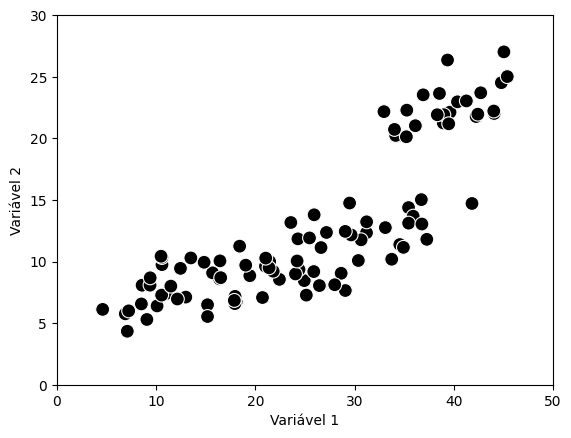

In [320]:
palette = {'o':'black', '+':'black'}
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

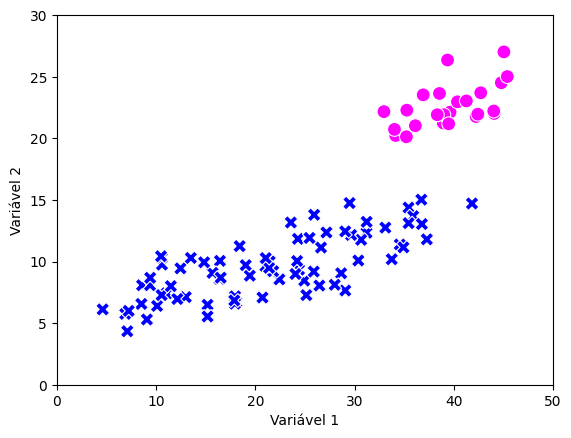

In [321]:
palette = {'o':'blue', '+':'magenta'}
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    style='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

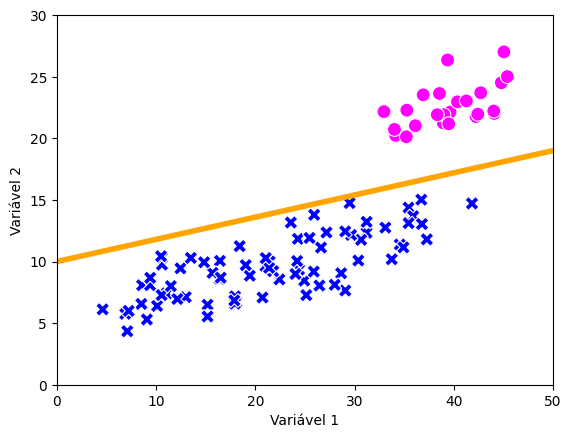

In [322]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    style='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.plot(
    [0, 50], # x
    [10, 19], # y
    c='orange',
    linewidth=4
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

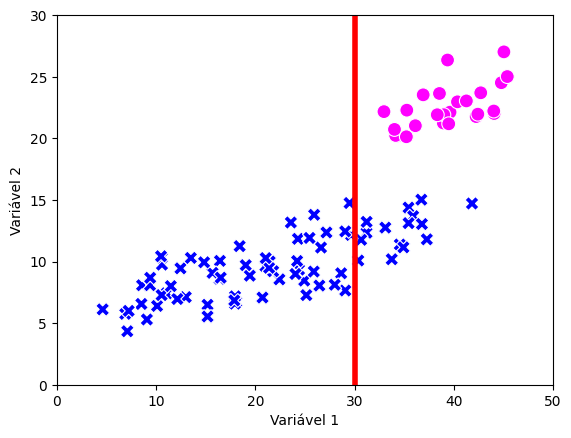

In [323]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    style='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.plot(
    [30, 30], # x
    [0, 30], # y
    c='r',
    linewidth=4
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

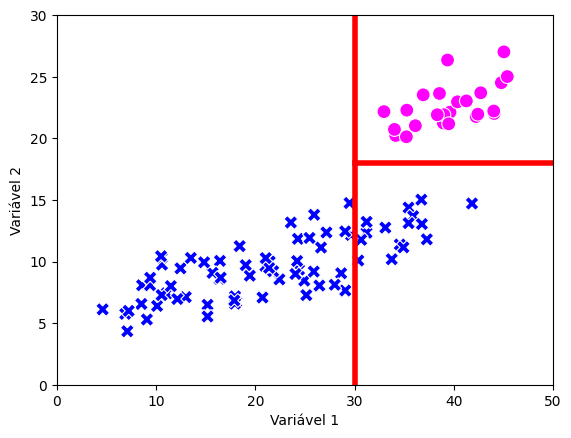

In [324]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    style='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.plot(
    [30, 30], # x
    [0, 30], # y
    c='r',
    linewidth=4
)
plt.plot(
    [30, 50], # x
    [18, 18], # y
    c='r',
    linewidth=4
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

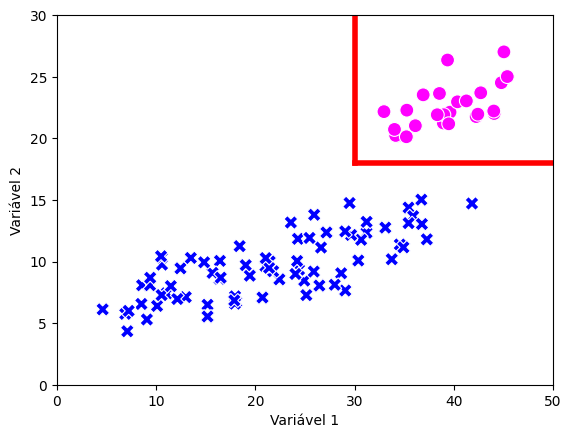

In [325]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    style='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.plot(
    [30, 30], # x
    [18, 30], # y
    c='r',
    linewidth=4
)
plt.plot(
    [30, 50], # x
    [18, 18], # y
    c='r',
    linewidth=4
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

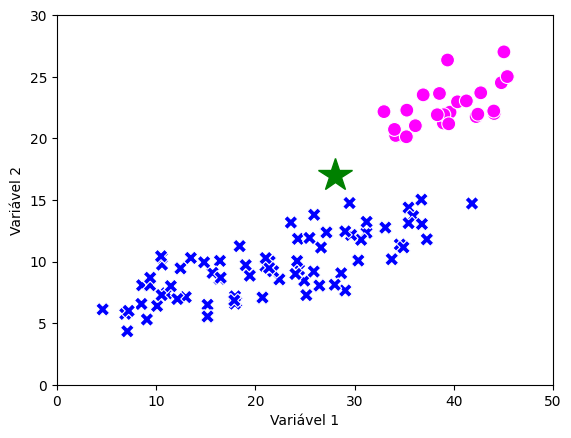

In [326]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    style='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.plot(
    28, 17, '*g', markersize=25
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

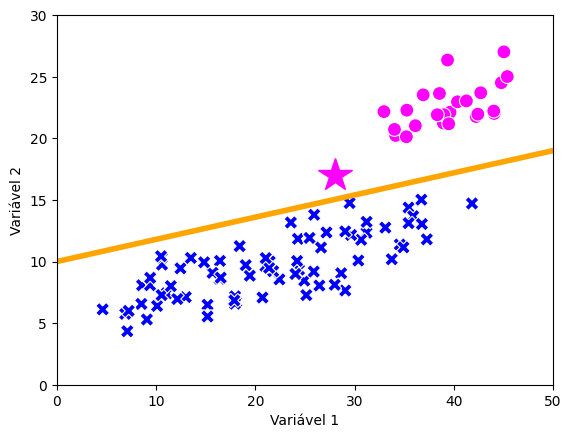

In [327]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    style='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.plot(
    28, 17, '*', c=palette['+'], markersize=25
)
plt.plot(
    [0, 50], # x
    [10, 19], # y
    c='orange',
    linewidth=4
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

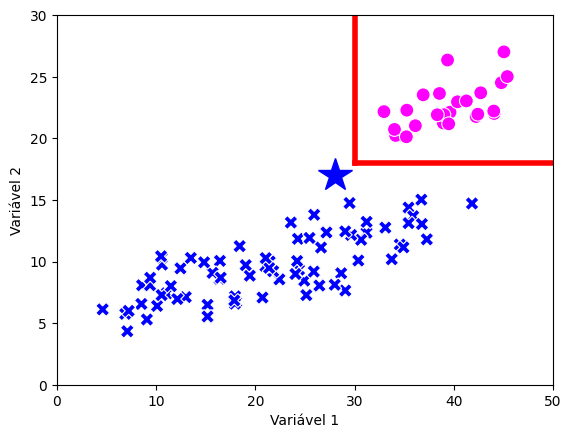

In [328]:
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    style='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=df_1
)
plt.plot(
    28, 17, '*', c=palette['o'], markersize=25
)
plt.plot(
    [30, 30], # x
    [18, 30], # y
    c='r',
    linewidth=4
)
plt.plot(
    [30, 50], # x
    [18, 18], # y
    c='r',
    linewidth=4
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

---

In [329]:
n = 50
x = np.random.randint(5, 45, n)
y = np.random.randint(5, 30, n)
df_nova = pd.DataFrame({'x':x,'y':y})
df_nova.head()

,x,y
0,10,24
1,15,19
2,17,10
3,42,20
4,39,13


In [330]:
palette = {'x':'blue', 'y':'magenta'}
df_nova['class'] = palette['x']
df_nova.loc[df_nova[df_nova['y'] >= 15].index, 'class'] = palette['y']
df_nova.head()

,x,y,class
0,10,24,magenta
1,15,19,magenta
2,17,10,blue
3,42,20,magenta
4,39,13,blue


In [331]:
# dump(df_nova, './data/01_aula_df_nova')
df_nova = load('./data/01_aula_df_nova')

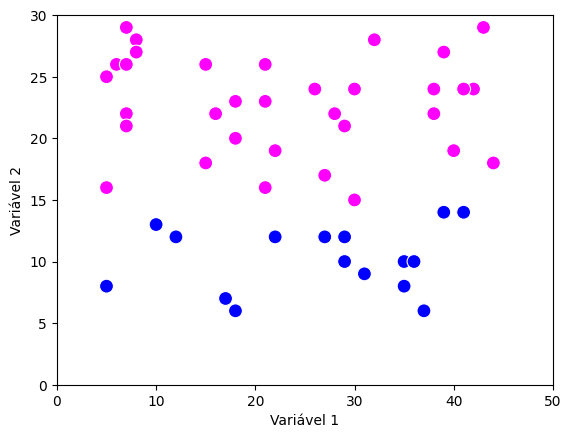

In [332]:
palette = {'magenta': 'magenta', 'blue': 'blue'}
sns.scatterplot(
    x='x',
    y='y',
    hue='class',
    palette=palette,
    legend=False,
    s=100,
    data=df_nova
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

In [333]:
display(len(df_nova[df_nova['class'] == "blue"]))
display(len(df_nova[df_nova['class'] == "blue"])/50*100)
display(len(df_nova[df_nova['class'] != "blue"]))
display(len(df_nova[df_nova['class'] != "blue"])/50*100)

17

34.0

33

66.0

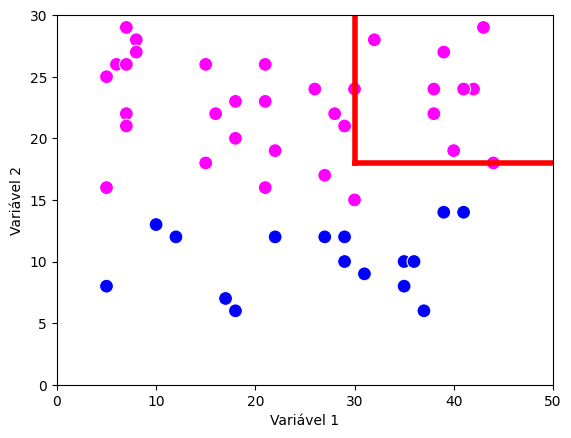

In [334]:
sns.scatterplot(
    x='x',
    y='y',
    hue='class',
    palette=palette,
    legend=False,
    s=100,
    data=df_nova
)
plt.plot(
    [30, 30], # x
    [18, 30], # y
    c='r',
    linewidth=4
)
plt.plot(
    [30, 50], # x
    [18, 18], # y
    c='r',
    linewidth=4
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

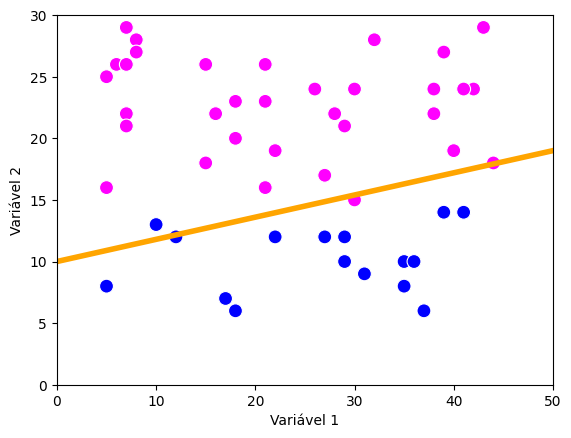

In [335]:
sns.scatterplot(
    x='x',
    y='y',
    hue='class',
    palette=palette,
    legend=False,
    s=100,
    data=df_nova
)
plt.plot(
    [0, 50], # x
    [10, 19], # y
    c='orange',
    linewidth=4
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

---

In [336]:
x = np.random.randint(543, 592, n)
x

array([555, 567, 548, 550, 549, 545, 584, 565, 576, 575, 576, 585, 562,
       566, 567, 551, 578, 546, 557, 567, 546, 564, 579, 565, 552, 578,
       558, 563, 584, 576, 581, 557, 564, 580, 572, 548, 583, 570, 563,
       571, 567, 579, 574, 553, 579, 589, 580, 551, 551, 562])

In [337]:
np.mean(x)

566.16

In [338]:
np.median(x)

566.5

In [339]:
np.std(x)

12.365047513050648

---

In [340]:
dados = df_1.sample(50).copy()
# dump(dados, "./data/01_aula_dados")
dados = load("./data/01_aula_dados")
dados.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2
50,31,13,31.210753,12.337848,12.337848,17,15,False,o,o
42,25,10,26.625263,11.133190,11.133190,9,5,False,o,o
171,13,4,10.498330,5.430175,10.430175,42,16,False,o,o
17,33,14,34.565248,11.379946,11.379946,15,3,True,+,o
163,15,5,18.423896,6.248151,11.248151,37,22,False,o,o


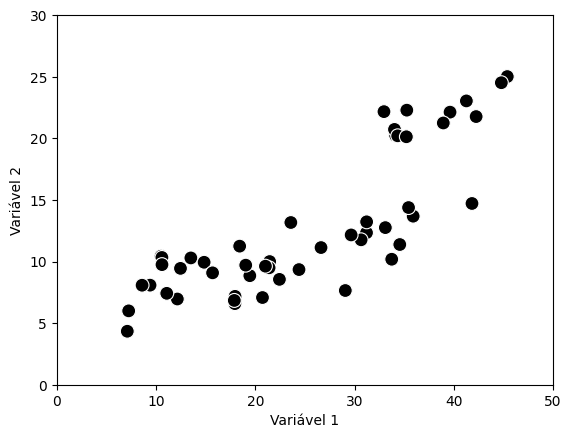

In [341]:
palette = {'o':'black', '+':'black'}
sns.scatterplot(
    x='x_noise',
    y='y_noise_new',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([0,30])
plt.show()

In [342]:
curva = Line_equation(
    dados=dados.loc[:, ['x_noise', 'y_noise_new']],
    coluna_x='x_noise',
    coluna_y='y_noise_new',
)
curva.equacao_da_reta_calculo()

25.01274246669294

In [343]:
dados.loc[:, ['x_noise', 'y_noise_new']].max()

x_noise        45.401363
y_noise_new    25.012742
dtype: float64

In [344]:
dados.loc[:, ['x_noise', 'y_noise_new']].min()

x_noise        7.096160
y_noise_new    4.340706
dtype: float64

In [345]:
curva.equacao_da_reta_calculo(new_y=dados.loc[:, ['x_noise', 'y_noise_new']].max()[0])

25.01274246669294

In [346]:
curva.equacao_da_reta_calculo(new_y=dados.loc[:, ['x_noise', 'y_noise_new']].min()[0])

4.340706297487653

In [347]:
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.equacao_da_reta_calculo, args=[12,])
normalizador = 37
dados['y_noise_new_cal'] = dados['y_noise_new']*normalizador
dados.head()

,x,y,x_noise,y_noise,y_noise_new,x_noise_mean,y_noise_mean,class,style,style_2,y_noise_calculo,y_noise_new_cal
50,31,13,31.210753,12.337848,12.337848,17,15,False,o,o,27.199224,456.500358
42,25,10,26.625263,11.133190,11.133190,9,5,False,o,o,24.229661,411.928023
171,13,4,10.498330,5.430175,10.430175,42,16,False,o,o,13.785862,385.916475
17,33,14,34.565248,11.379946,11.379946,15,3,True,+,o,29.371594,421.058007
163,15,5,18.423896,6.248151,11.248151,37,22,False,o,o,18.918457,416.181574


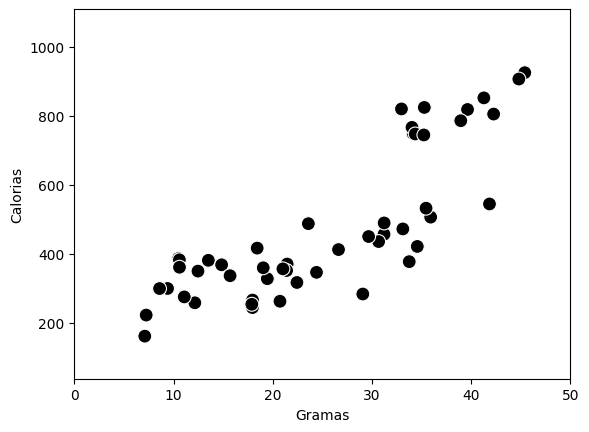

In [348]:
obsr = 'Gramas'
pred = 'Calorias'
palette = {'o':'black', '+':'black'}
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

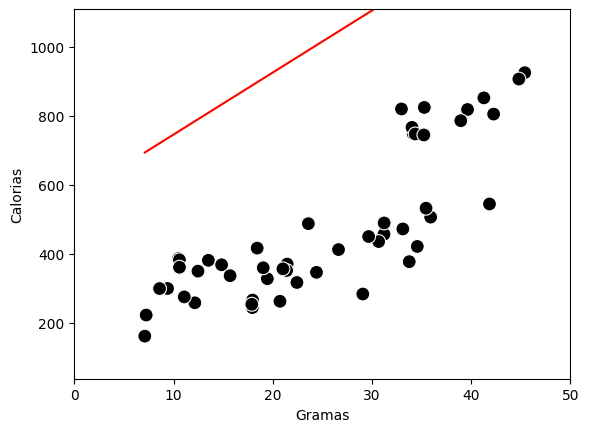

In [349]:
dados_reta = [566, 18,]
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

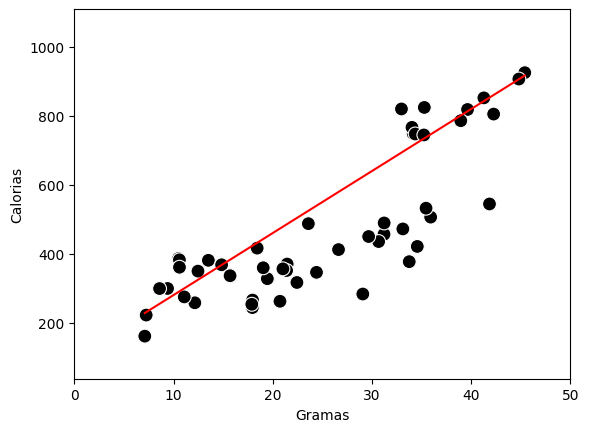

In [350]:
dados_reta = [100, 18,]
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

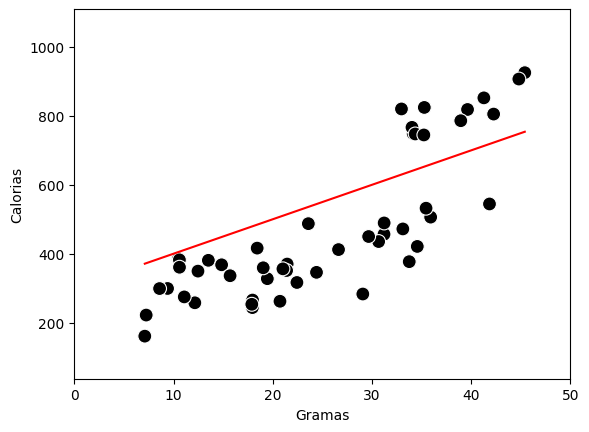

In [351]:
dados_reta = [300, 10,]
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

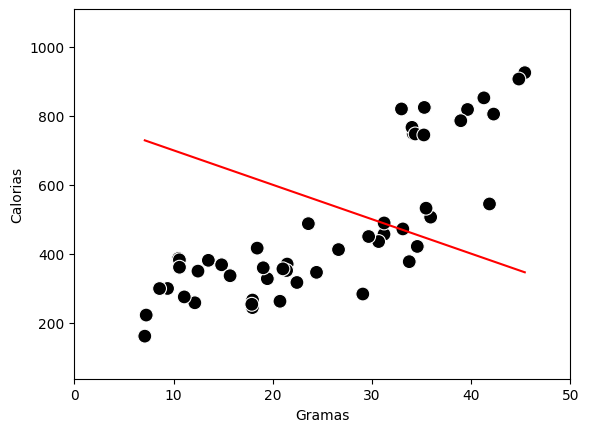

In [352]:
dados_reta = [800, -10,]
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

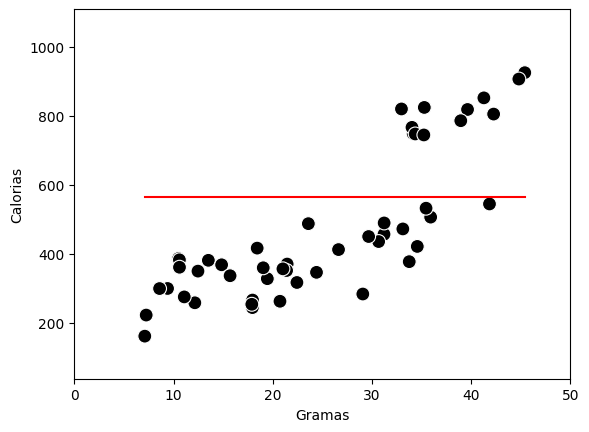

In [353]:
dados_reta = [566, 0,]
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

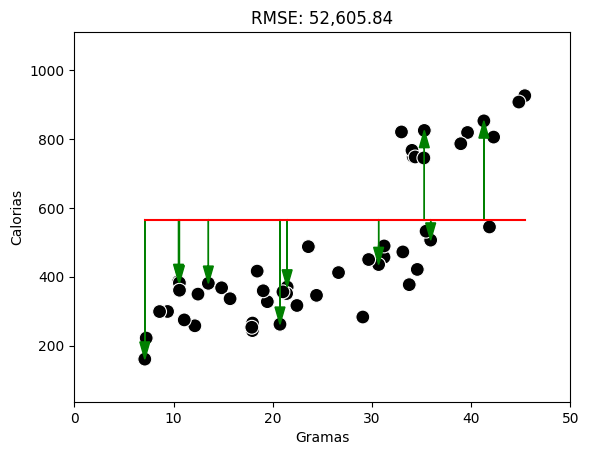

In [354]:
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
for n in range(10):
    index = dados['x_noise'].sample(1).index[0]
    x = dados['x_noise'][index]
    y = dados['y_noise_calculo'][index]
    d = dados['y_noise_new_cal'][index] - y

    plt.arrow(
        x,
        y,
        0,
        d,
        head_width=1,
        head_length=50,
        length_includes_head=True,
        color='g',
    )
rmse = mean_squared_error(dados['y_noise_calculo'],dados['y_noise_new_cal'])
plt.title(f"RMSE: {rmse:,.2f}")
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

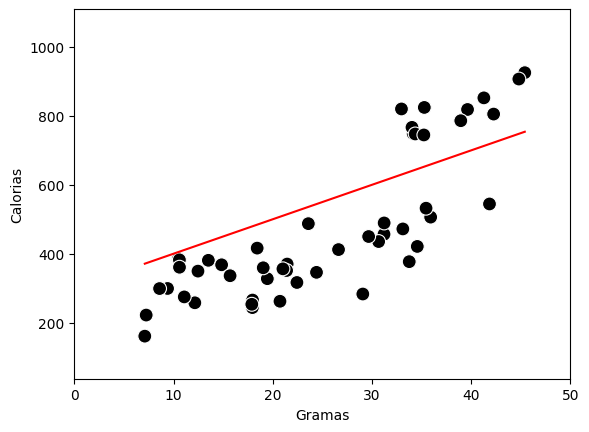

In [355]:
dados_reta = [300, 10,]
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

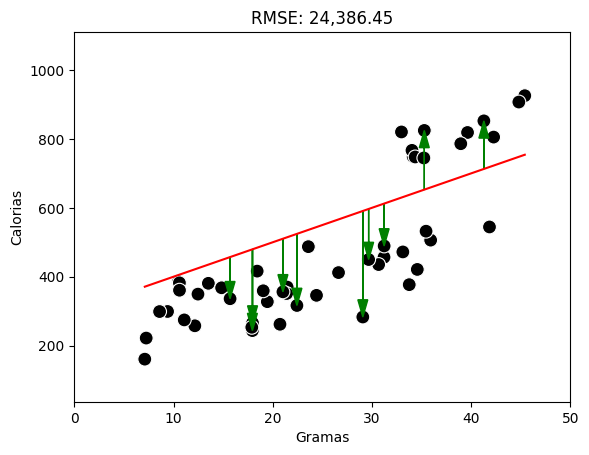

In [356]:
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
for n in range(10):
    index = dados['x_noise'].sample(1).index[0]
    x = dados['x_noise'][index]
    y = dados['y_noise_calculo'][index]
    d = dados['y_noise_new_cal'][index] - y

    plt.arrow(
        x,
        y,
        0,
        d,
        head_width=1,
        head_length=50,
        length_includes_head=True,
        color='g',
    )
rmse = mean_squared_error(dados['y_noise_calculo'],dados['y_noise_new_cal'])
plt.title(f"RMSE: {rmse:,.2f}")
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

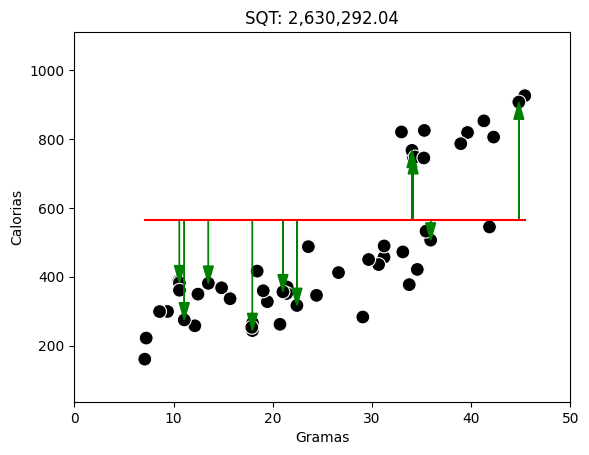

In [357]:
dados_reta = [566, 0,]
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
for n in range(10):
    index = dados['x_noise'].sample(1).index[0]
    x = dados['x_noise'][index]
    y = dados['y_noise_calculo'][index]
    d = dados['y_noise_new_cal'][index] - y

    plt.arrow(
        x,
        y,
        0,
        d,
        head_width=1,
        head_length=50,
        length_includes_head=True,
        color='g',
    )
sst =np.sum((dados['y_noise_new_cal'] - dados['y_noise_calculo'])**2)
plt.title(f"SQT: {sst:,.2f}")
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

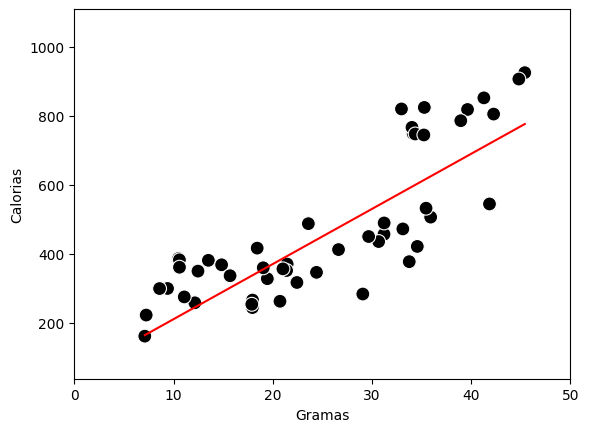

In [358]:
dados_reta = [50, 16,]
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

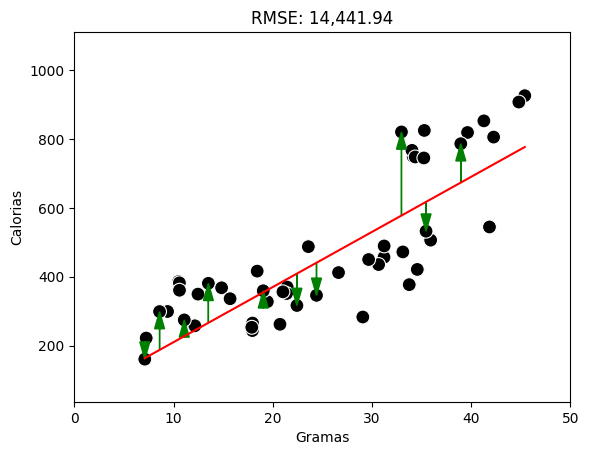

In [359]:
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
for n in range(10):
    index = dados['x_noise'].sample(1).index[0]
    x = dados['x_noise'][index]
    y = dados['y_noise_calculo'][index]
    d = dados['y_noise_new_cal'][index] - y

    plt.arrow(
        x,
        y,
        0,
        d,
        head_width=1,
        head_length=50,
        length_includes_head=True,
        color='g',
    )
rmse = mean_squared_error(dados['y_noise_calculo'],dados['y_noise_new_cal'])
plt.title(f"RMSE: {rmse:,.2f}")
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

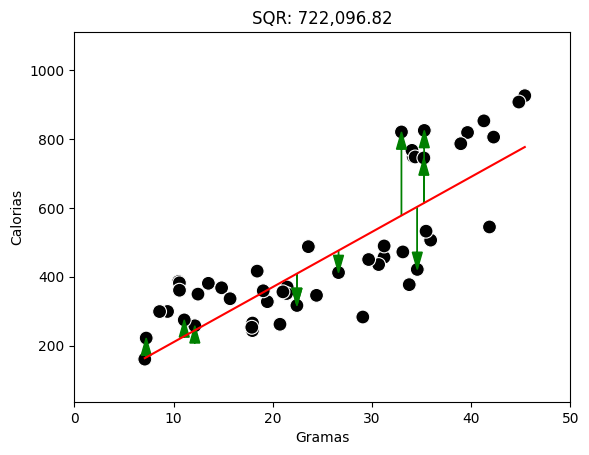

In [360]:
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)
for n in range(10):
    index = dados['x_noise'].sample(1).index[0]
    x = dados['x_noise'][index]
    y = dados['y_noise_calculo'][index]
    d = dados['y_noise_new_cal'][index] - y

    plt.arrow(
        x,
        y,
        0,
        d,
        head_width=1,
        head_length=50,
        length_includes_head=True,
        color='g',
    )
ssr = np.sum((dados['y_noise_new_cal'] - dados['y_noise_calculo'])**2)
plt.title(f"SQR: {ssr:,.2f}")
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

In [362]:
r2 = 1-(ssr/sst)
r2

0.7254689561257941

In [363]:
tam = len(dados['y_noise_new_cal'])
r2a = 1 - (tam/(tam-1))*(1-r2)
r2a

0.7198662817610144

In [364]:
y_obs = dados['y_noise_new_cal']
y_pred = dados['y_noise_calculo']
r2_score(y_obs, y_pred)

0.6687057250989165

In [365]:
mae = np.sum(((y_obs - y_pred)**2)**0.5)/tam
mae

105.53059627579107

In [366]:
mean_absolute_error(y_obs, y_pred)

105.53059627579107

In [367]:
mse = np.sum((y_obs - y_pred)**2)/tam
mse

14441.936393214384

In [368]:
mean_squared_error(y_obs, y_pred)

14441.936393214384

In [369]:
rmae = mae**0.5
rmae

10.272808587518366

In [370]:
root_mean_squared_error(y_obs, y_pred)

120.17460793867556

In [371]:
mape = np.sum((((y_obs - y_pred)**2)**0.5)/y_obs)/tam
mape

0.23873286041624758

In [372]:
mean_absolute_percentage_error(y_obs, y_pred)

0.23873286041624758

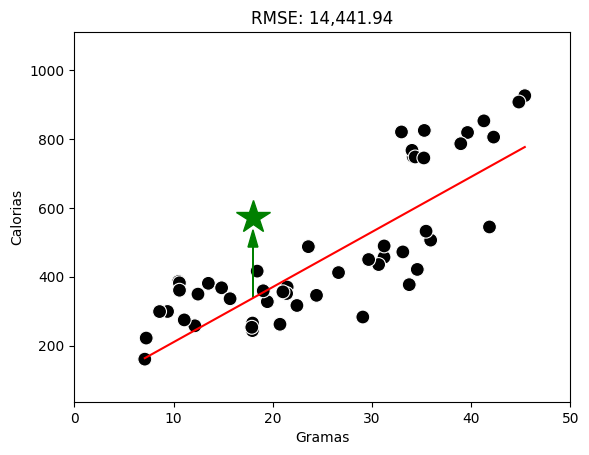

In [373]:
dados['y_noise_calculo'] = dados['x_noise'].apply(curva.reta, args=dados_reta)
sns.scatterplot(
    x='x_noise',
    y='y_noise_new_cal',
    hue='style_2',
    legend=False,
    s=100,
    palette=palette,
    data=dados
)
sns.lineplot(
    x='x_noise',
    y='y_noise_calculo',
    data=dados,
    c='r',
)    
plt.plot(
    18, 572, '*', c='g', markersize=25
)
plt.arrow(
    18,
    340,
    0,
    196,
    head_width=1,
    head_length=50,
    length_includes_head=True,
    color='g',
)
rmse = mean_squared_error(dados['y_noise_calculo'],dados['y_noise_new_cal'])
plt.title(f"RMSE: {rmse:,.2f}")
plt.xlabel(obsr)
plt.ylabel(pred)
plt.xlim([0,50])
plt.ylim([normalizador,30*normalizador])
plt.show()

---

In [374]:
data = [
[2025,16537],
[2024,5434],
[2023,38871],
[2022,39224],
[2021,31559],
[2020,2278],
[2019,16472],
[2018,11267],
[2017,8257],
[2016,6832],
[2015,6803],
[2014,6908],
[2013,6832],
[2012,5574],
[2011,5314],
[2010,4491],
[2009,4642],
[2008,4906],
[2007,4467],
[2006,4065],
[2005,3639],
[2004,2762],
[2003,1802],
[2002,1462],
[2001,1343],
[2000,1248],
[1999,106],
[1998,1025],
[1997,982],
[1996,862],
[1995,905],
[1994,729],
[1993,61],
[1992,438],
[1991,456],
[1990,372],
[1989,295],
[1988,219],
[1987,198],
[1986,165],
[1985,65],
[1984,3],
[1983,23],
[1982,13],
[1981,11],
[1980,12],
[1979,4],
[1978,3],
[1977,5],
[1976,7],
[1975,5],
[1974,7],
[1973,6],
[1972,5],
[1971,3],
[1970,2],
[1969,1],
[1968,5],
[1967,3],
[1966,2],
[1965,4],
[1964,5],
[1963,5],
[1962,6],
[1961,3],
[1960,1],
[1958,1],
[1956,1],
[1954,1],
[1953,1],
[1952,1],
[1951,1],
]
dados_pubmed = pd.DataFrame(data)
dados_pubmed.rename(columns={0: 'Year', 1: 'Works'}, inplace=True)
dados_pubmed.head()

,Year,Works
0,2025,16537
1,2024,5434
2,2023,38871
3,2022,39224
4,2021,31559


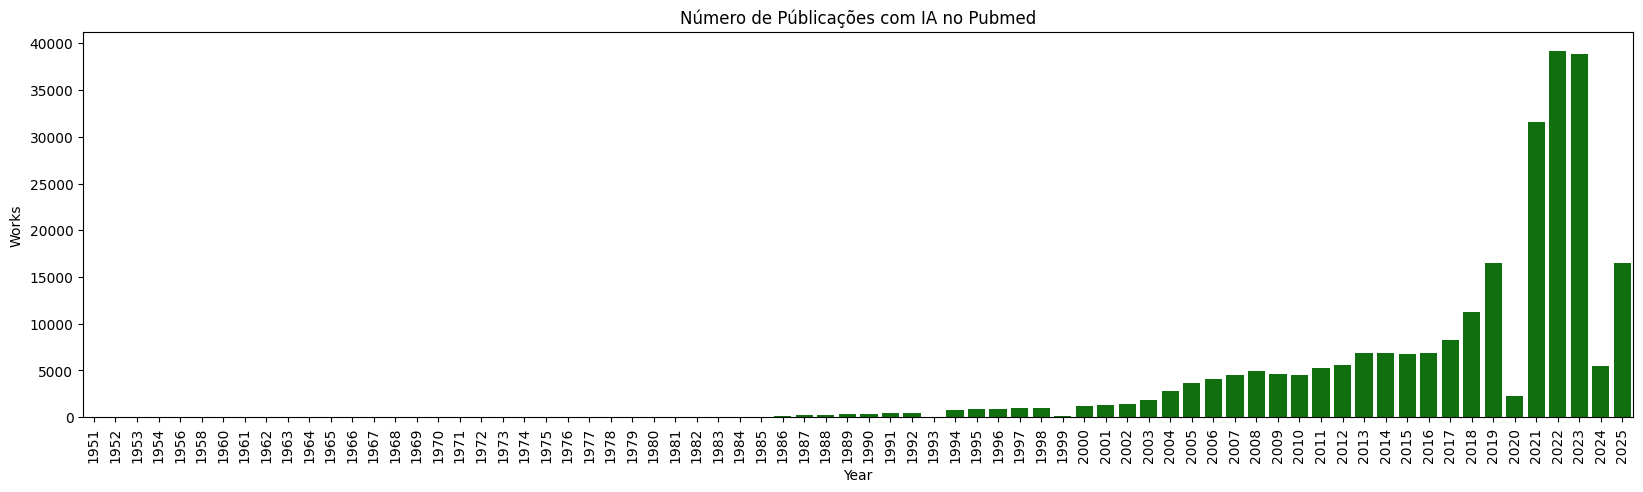

In [375]:
plt.figure(figsize=(20,5))
plt.title('Número de Públicações com IA no Pubmed')
sns.barplot(
    x='Year',
    y='Works',
    color='green',
    data=dados_pubmed
)
plt.xticks(rotation=90)
plt.show()